# Визначення пневмонії за рентген-знімками
## Бізнес-контекст
Компанія MediScan AI впроваджує модель, яка за рентген-знімками грудної клітки визначає наявність пневмонії.
Вам необхідно створити і навчити таку модель, використовуючи transfer learning і методи регуляризації.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = './data/chest_xray'
subdirs = ['test', 'train', 'val']
mean = [0.485, 0.485, 0.485]
std = [0.229, 0.229, 0.229]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize( mean, std )
])

img_datasets = {
    s: datasets.ImageFolder(root=f"{data_dir}/{s}", transform=transform)
    for s in subdirs
}

dataloaders = {
    s: DataLoader(img_datasets[s], batch_size=32, shuffle=(s=='train'), num_workers=4)
    for s in subdirs 
}

class_names = img_datasets[subdirs[0]].classes
print(class_names)

['NORMAL', 'PNEUMONIA']


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = np.transpose(img.numpy(), (1,2,0))
    img = img * std + mean
    img = img.clip(0,1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

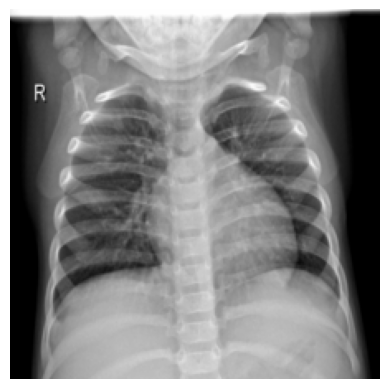

In [3]:
images, labels = next( iter(dataloaders['train']))
imshow(images[0])

## Завдання 2
Використовуйте переднавчену модель ResNet18.

- Заморозьте згорткові шари.
- Замініть класифікатор на новий (Linear(512, 2)).
- Функція втрат: CrossEntropyLoss.
- Оптимізатор: Adam (lr=0.0001).
- Навчіть 5 епох.

In [8]:
import torchvision
resnet18 = torchvision.models.resnet18(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ancie/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [9]:
for param in resnet18.parameters():
    param.requires_grad = False

# Замініть класифікатор на новий (Linear(512, 2)).
num_features = resnet18.fc.in_features

resnet18.fc = torch.nn.Linear(num_features, 2)
print(num_features)

512


In [10]:
loss_f = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet18.parameters(), lr=0.0001)

In [ ]:
# epochs = 5
# for epoch in range(epochs):
#     with torch.no_grad():
#         for images, labels in dataloaders['train']:
#             _, pred = torch.max(resnet18)